# Part B - MDS-UPDRS Part III Subpart Analysis

### TEST the SUM of the question for each of the coloured boxes (ABOVE) within Part 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import palettable.wesanderson as wes

import sys
sys.path.insert(0 , './../MDS-UPDRS_Analysis/')
import distributions
from distributions import *

%load_ext autoreload
%autoreload 2

# Get Idiopathic IDs

In [2]:
meta = pd.read_csv('./../../data/PPMI/MO-LLM/PPMI_META_LINKAGE.csv')
idiopathic_ids = meta[np.logical_and(meta['Subgroup'] == 'Sporadic' , meta['CONCOHORT_DEFINITION'] == "Parkinson's Disease")]['PATNO'].unique()

# Specify Event IDs for which Genomic Data is Available

In [3]:
events = ['BL', 'V02' , 'V04' ,'V05',
          'V06' ,'V07' , 'V08' ,'V09' , 'V10' ,
          'V11' , 'V12' ,'V13' , 'V14' ,'V15' ,
          'V16' , 'V17' , 'V18','V19' ,'V20' ]

all_events = ['SC', 'BL', 'V01', 'V02', 'V03', 'V04', 'V05',
'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12',
'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
'ST', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25'
]

x_list = pd.DataFrame(np.arange(0 , 9.5 , 0.5) , index = events , columns=['response'])

# MDS-UPDRS Part III

In [4]:
p3 = pd.read_csv('./../Assesment_Exams/MDS-UPDRS_Part_III_21Jan2025.csv')
p3 = p3[p3['PDSTATE'].isin([np.nan , 'OFF'])]
p3_final = p3.loc[: , ['PATNO' , 'EVENT_ID'] + [col for col in p3.columns if 'NP3' in col]]
p3_final = p3_final.replace(101, np.nan).drop_duplicates()

p3_final = p3_final[p3_final['PATNO'].isin(idiopathic_ids)]

p3_meta = p3.loc[ : , ['PATNO' , 'EVENT_ID' , 'PDTRTMNT' , 'PDSTATE' , 'HRPOSTMED' , 'HRDBSON', 'HRDBSOFF', 'PDMEDYN', 'DBSYN', 'ONOFFORDER', 'OFFEXAM', 'OFFNORSN', 'DBSOFFTM', 'ONEXAM', 'ONNORSN' ]]

In [5]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(p3_final['PATNO'].unique())) , 'PATNO' : np.repeat(p3_final['PATNO'].unique() , len(events))})

p3_final = p3_final[p3_final['EVENT_ID'].isin(events)]
p3_impute = pd.merge(all_tmpt , p3_final , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
p3_impute['EVENT_ID'] = pd.Categorical(p3_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in p3_impute['PATNO'].unique() : 
    row_na = False
    df = p3_impute[p3_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    p3_impute[p3_impute['PATNO'] == patno] = df.copy()

p3 = p3_impute[np.logical_and(p3_impute['PATNO'].isin(idiopathic_ids) , p3_impute['EVENT_ID'].isin(events))]

# Rigidity

In [6]:
rigidity = ['NP3RIGN',
'NP3RIGRU',
'NP3RIGLU',
'NP3RIGRL',
'NP3RIGLL']

In [7]:
p3['NP3RIG'] = [np.nan for i in range(p3.shape[0])]

p3['NP3RIG'] = p3['NP3RIG'].fillna(p3.dropna(subset=rigidity).loc[: , rigidity].sum(axis=1))

p3.pivot_table(values = 'NP3RIG' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartB_Rigidity_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 2.518758077487981
Estimated beta (rate): 0.6201165296399133


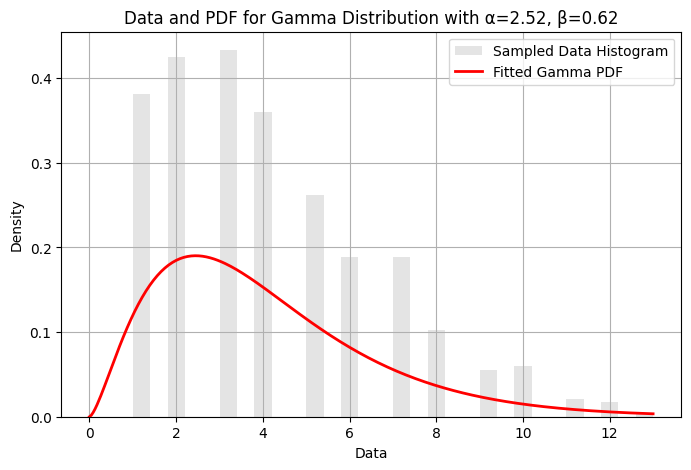

Gamma AIC : 2584.046433446615
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 2.586212140288125
Estimated beta (rate): 0.572993110570936


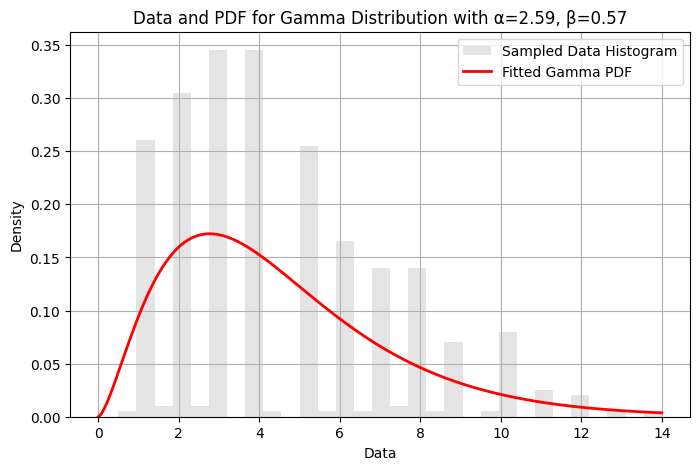

Gamma AIC : 2054.514508490428
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 2.6263527692592064
Estimated beta (rate): 0.5386759718145139


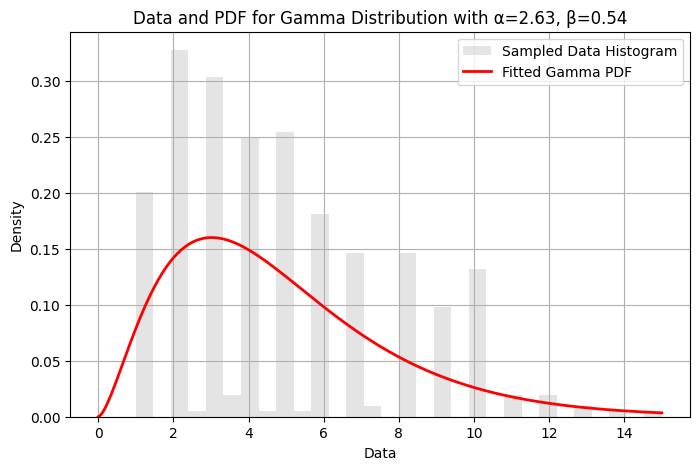

Gamma AIC : 2089.72322596846
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 2.3903372963931213
Estimated beta (rate): 0.44791929767368444


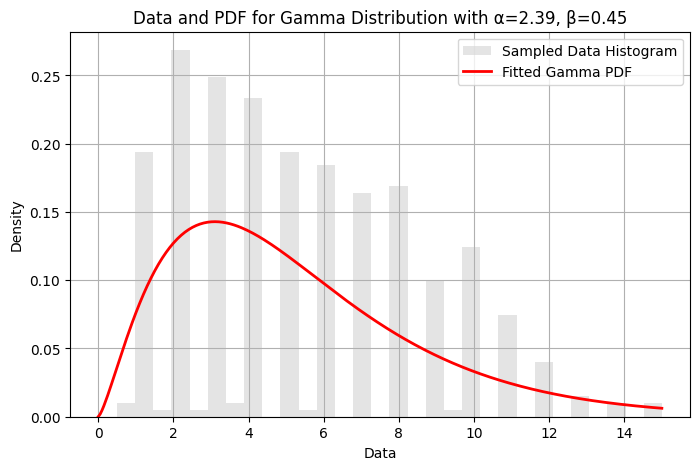

Gamma AIC : 2086.695075891666
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 3.0617728266569046
Estimated beta (rate): 0.5392994908898823


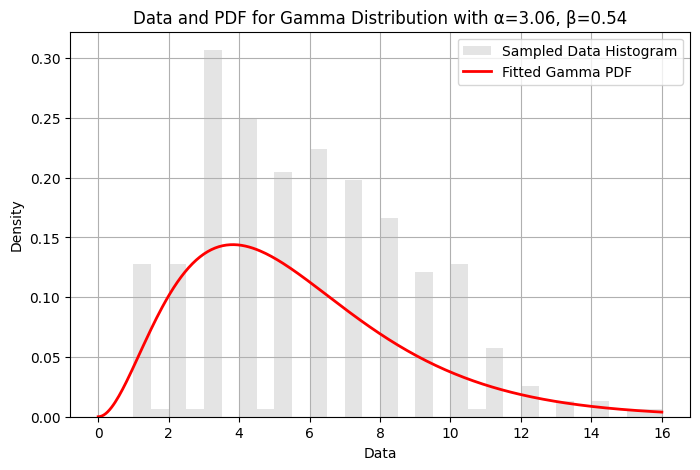

Gamma AIC : 1555.1531571044072
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 3.108722397025823
Estimated beta (rate): 0.4991670796485956


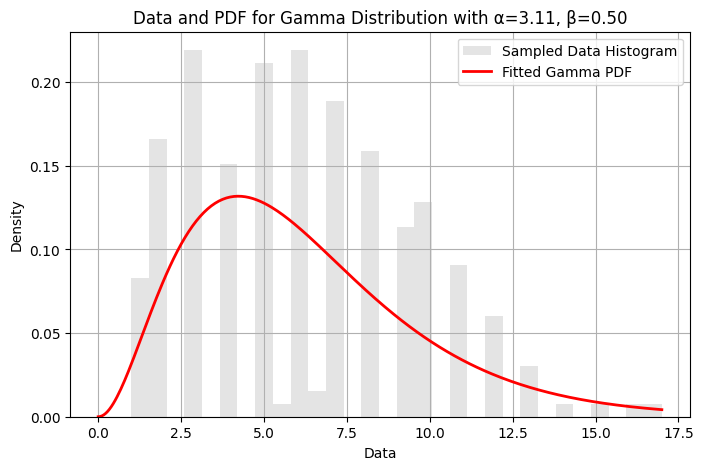

Gamma AIC : 1276.1116556306824
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 3.35619671250494
Estimated beta (rate): 0.5172634621860637


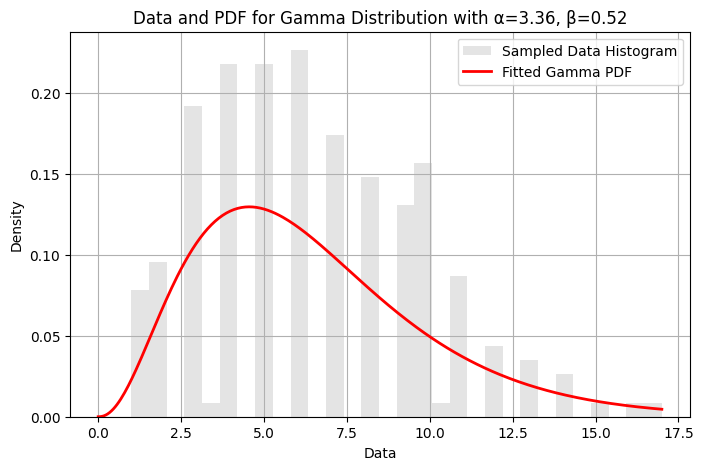

Gamma AIC : 1111.9415741792823
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 2.713056381300583
Estimated beta (rate): 0.4177166097952485


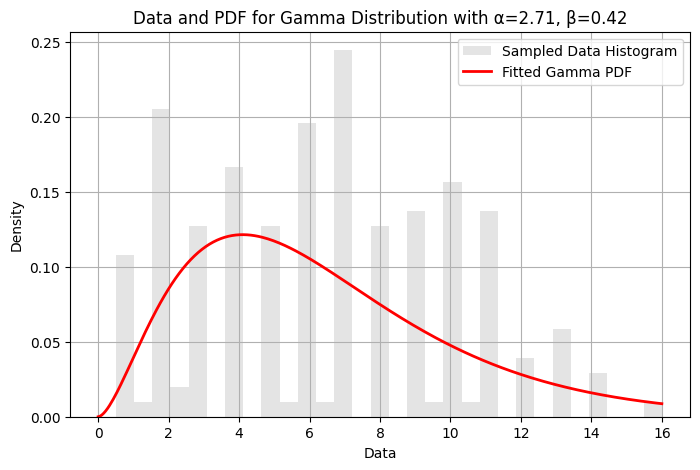

Gamma AIC : 1055.918486910883
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 2.6167272769775334
Estimated beta (rate): 0.3738166907324591


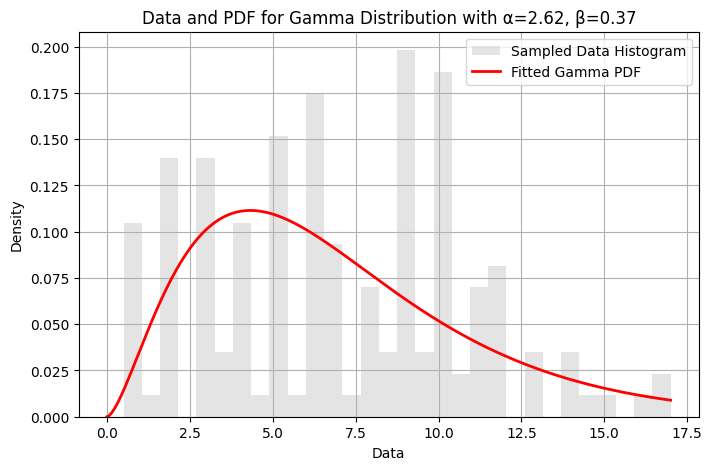

Gamma AIC : 860.1007752535866


In [10]:
rigidity_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')[rigidity].sum(axis=1)
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    rigidity_label = pd.concat([rigidity_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [12]:
rigidity_label.to_csv('./../Labels/PartB_Rigidity_Labels.csv')

## Finger Tapping

In [8]:
finger_tapping = ['NP3FTAPR',
'NP3FTAPL']

In [9]:
p3['NP3FTP'] = [np.nan for i in range(p3.shape[0])]

p3['NP3FTP'] = p3['NP3FTP'].fillna(p3.dropna(subset=finger_tapping).loc[: , finger_tapping].sum(axis=1))

p3.pivot_table(values = 'NP3FTP' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartB_FingerTap_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 3.55736134420052
Estimated beta (rate): 1.484179964416358


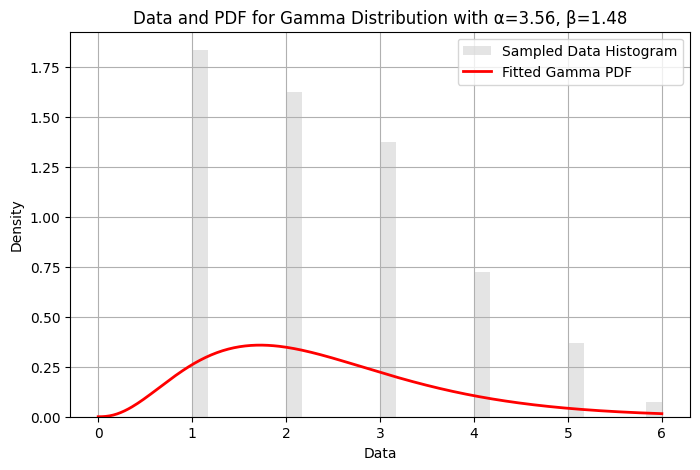

Gamma AIC : 1786.477227518078
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 3.5334798135720717
Estimated beta (rate): 1.382869131747773


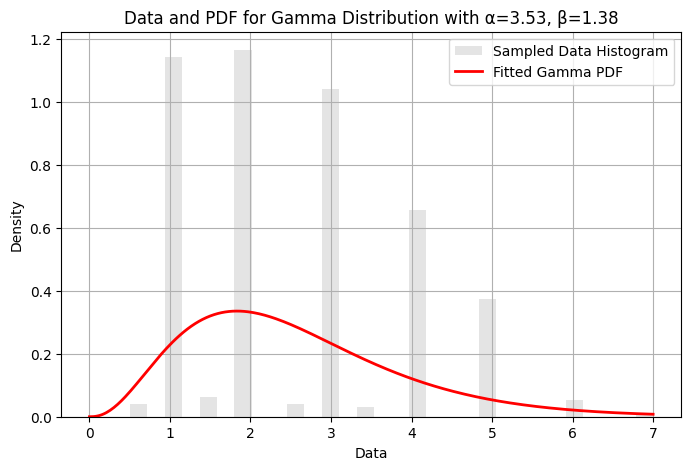

Gamma AIC : 1446.748887266889
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 3.3452401525568427
Estimated beta (rate): 1.2743772037748717


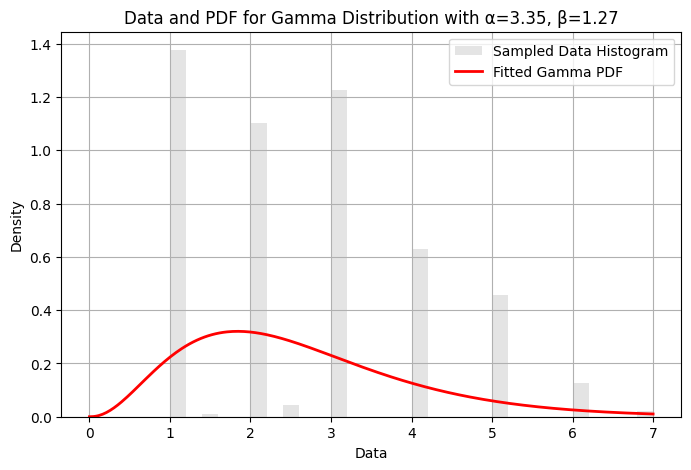

Gamma AIC : 1462.8011558430371
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 3.2014759007365785
Estimated beta (rate): 1.1461729945467327


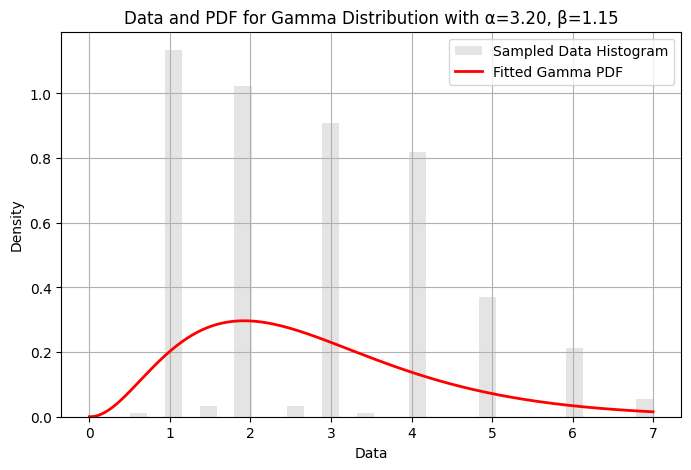

Gamma AIC : 1443.993660160864
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 3.857510274074285
Estimated beta (rate): 1.3489045491975677


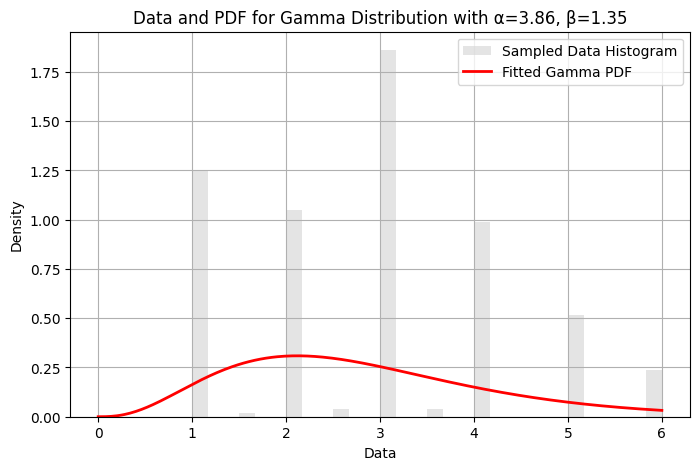

Gamma AIC : 1035.7108989340536
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 3.4565780155499786
Estimated beta (rate): 1.1931335747861318


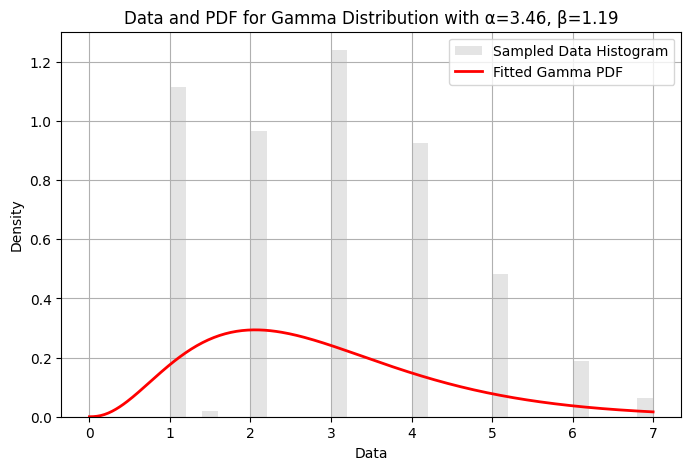

Gamma AIC : 841.227771491924
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 3.1097633361385375
Estimated beta (rate): 1.036588016002844


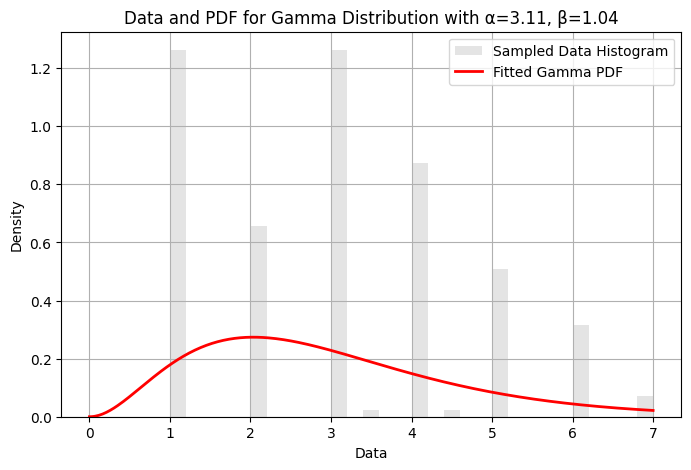

Gamma AIC : 759.6910381450695
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 3.433787137012083
Estimated beta (rate): 1.0577890903906153


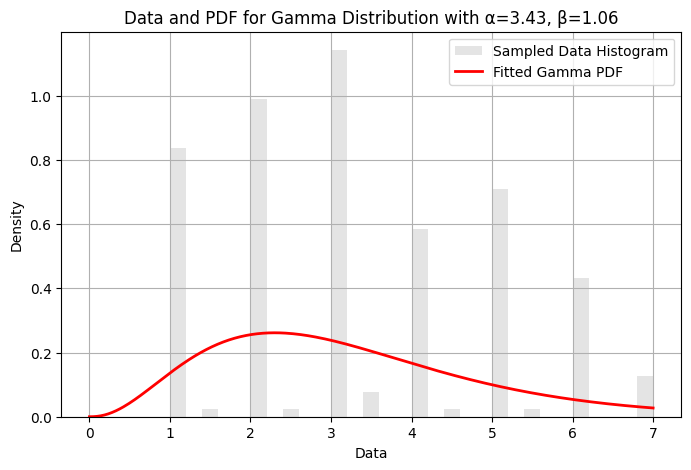

Gamma AIC : 742.8444972380337
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 4.1665386185557
Estimated beta (rate): 1.1457104568712435


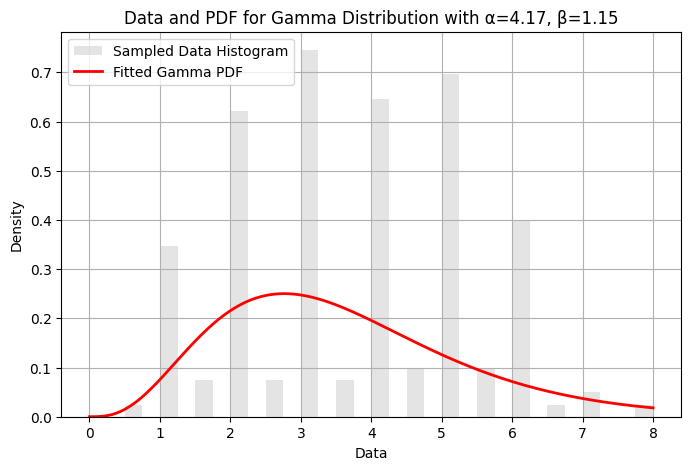

Gamma AIC : 619.5129418216272


In [14]:
fingertap_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')[finger_tapping].sum(axis=1)
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    fingertap_label = pd.concat([fingertap_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [15]:
fingertap_label

,BL,V02,V04,V06,V08,V10,V12,V14,V16
PATNO,,,,,,,,,
3001,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Worse,Worse
3002,Not Worse,Not Worse,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Worse,Not Worse
3003,Not Worse,Worse,Worse,Worse,Worse,Worse,Not Worse,Not Worse,Not Worse
3006,Worse,Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3007,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
...,...,...,...,...,...,...,...,...,...
160231,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
161236,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
162929,Not Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse


In [16]:
fingertap_label.to_csv('./../Labels/PartB_FingerTap_Labels.csv')

## Hand Movements

In [10]:
hand_movements = [
'NP3HMOVR',
'NP3HMOVL'
]

In [11]:
p3['NP3HMV'] = [np.nan for i in range(p3.shape[0])]

p3['NP3HMV'] = p3['NP3HMV'].fillna(p3.dropna(subset=hand_movements).loc[: , hand_movements].sum(axis=1))

p3.pivot_table(values = 'NP3HMV' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartB_HandMove_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 3.507615290148324
Estimated beta (rate): 1.6817333377088914


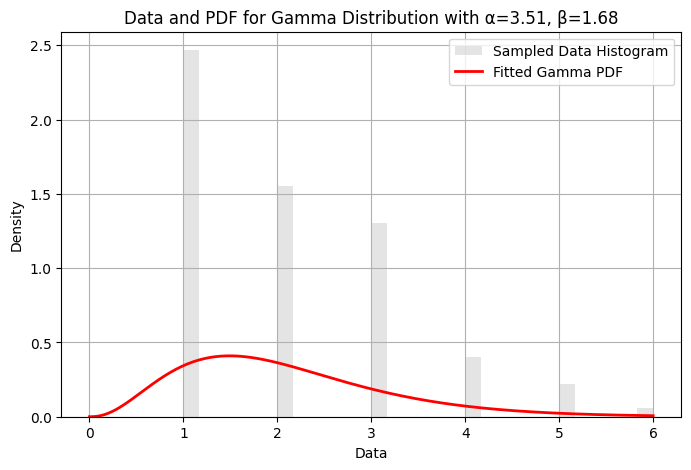

Gamma AIC : 1499.8101493855238
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 3.7531153137670894
Estimated beta (rate): 1.6604570264527267


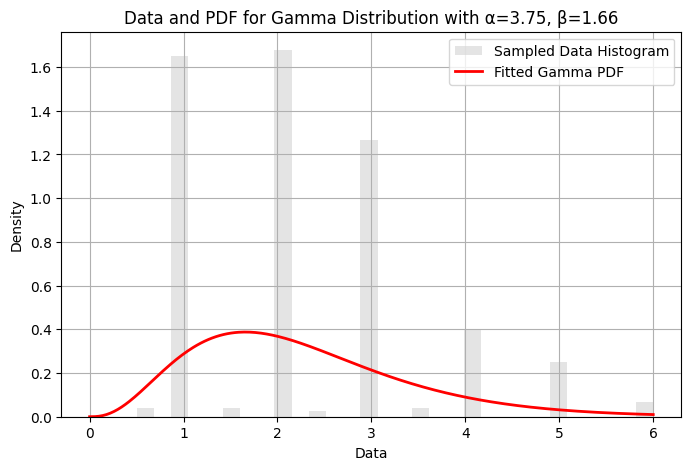

Gamma AIC : 1225.0296687429593
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 3.2576666309939335
Estimated beta (rate): 1.3883510414756821


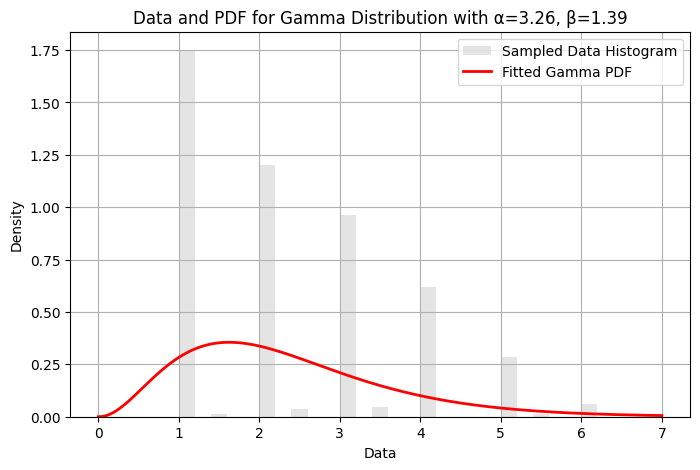

Gamma AIC : 1323.5674043258973
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 3.2335559508214877
Estimated beta (rate): 1.273977471485864


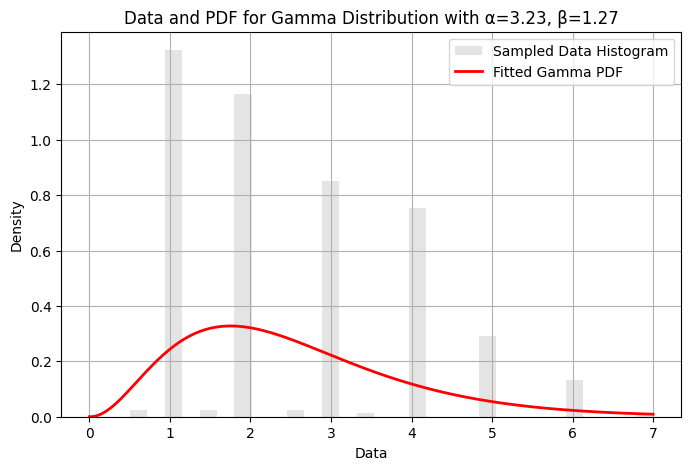

Gamma AIC : 1259.7380517798028
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 3.371042593572636
Estimated beta (rate): 1.2713393104630295


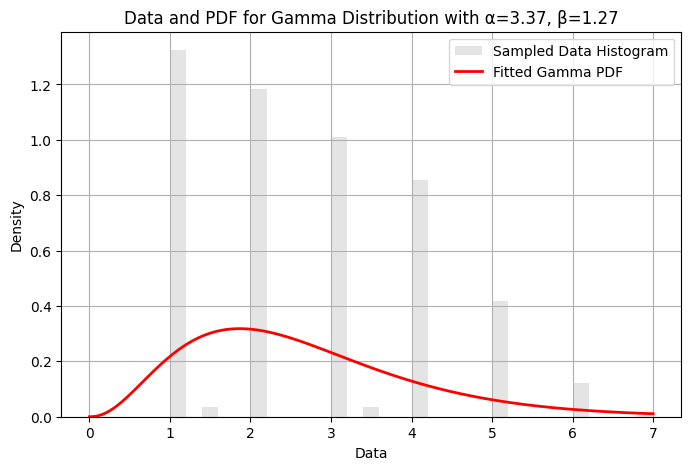

Gamma AIC : 968.3465348299972
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 3.4407323986586253
Estimated beta (rate): 1.3255752519606363


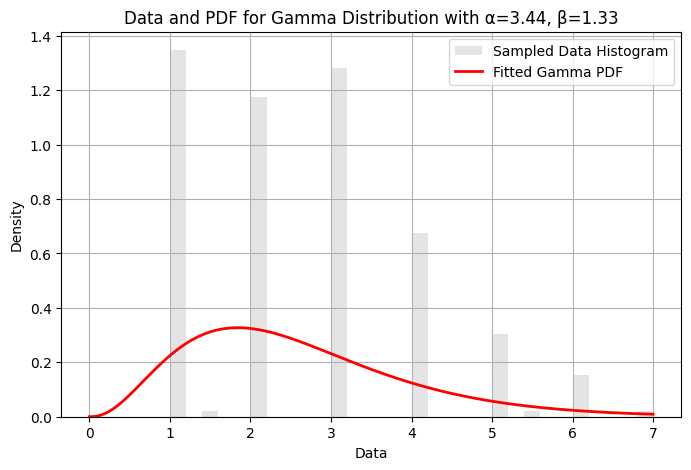

Gamma AIC : 763.3725695754301
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 3.2747868922560714
Estimated beta (rate): 1.2451178387501587


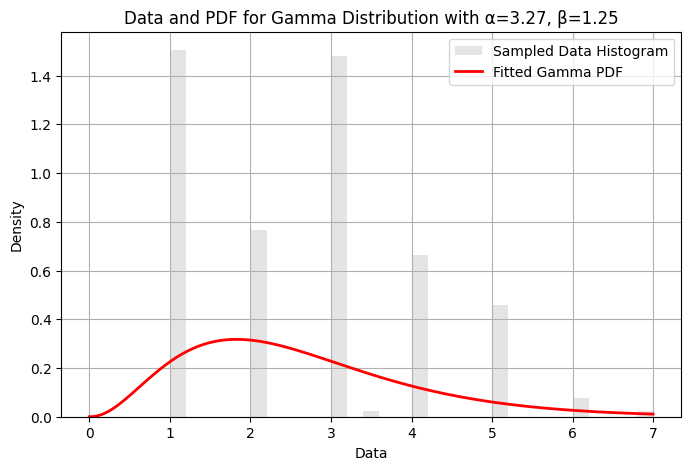

Gamma AIC : 663.7521623113945
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 3.237527767874907
Estimated beta (rate): 1.1250558868691394


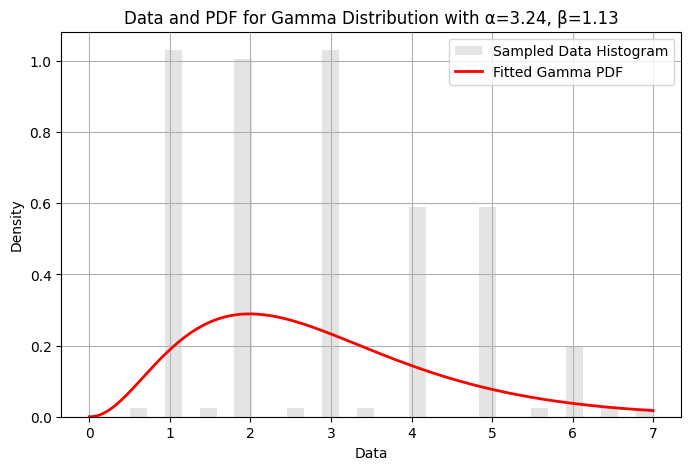

Gamma AIC : 672.2868210775648
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 3.434380360765077
Estimated beta (rate): 1.0161640969780976


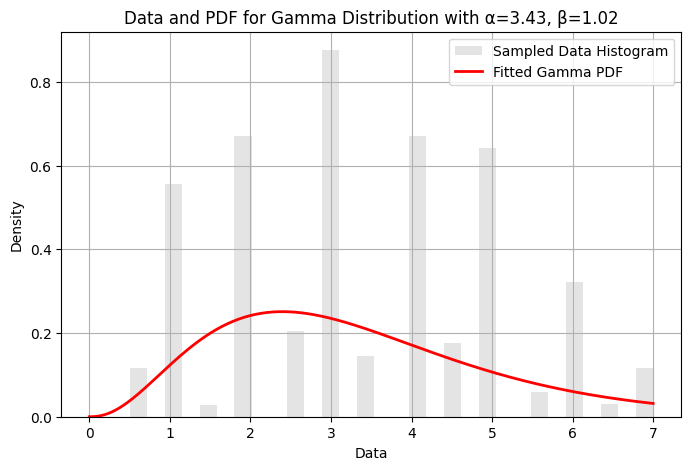

Gamma AIC : 609.2951141038875


In [18]:
handmov_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')[hand_movements].sum(axis=1)
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    handmov_label = pd.concat([handmov_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [19]:
handmov_label

,BL,V02,V04,V06,V08,V10,V12,V14,V16
PATNO,,,,,,,,,
3001,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Worse
3002,Worse,Not Worse,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Worse,Not Worse
3003,Worse,Worse,Worse,Worse,Worse,Worse,Not Worse,Not Worse,Not Worse
3006,Not Worse,Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3007,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
...,...,...,...,...,...,...,...,...,...
160231,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
161236,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
162929,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse


In [20]:
handmov_label.to_csv('./../Labels/PartB_HandMove_Labels.csv')

## PRONATION-SUPINATION MOVEMENTS OF HANDS

In [12]:
pron_sup = [
'NP3PRSPR',
'NP3PRSPL'
]

In [13]:
p3['NP3PSUP'] = [np.nan for i in range(p3.shape[0])]

p3['NP3PSUP'] = p3['NP3PSUP'].fillna(p3.dropna(subset=pron_sup).loc[: , pron_sup].sum(axis=1))

p3.pivot_table(values = 'NP3PSUP' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartB_PronSupHandMove_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 3.507585910341901
Estimated beta (rate): 1.7098259106207354


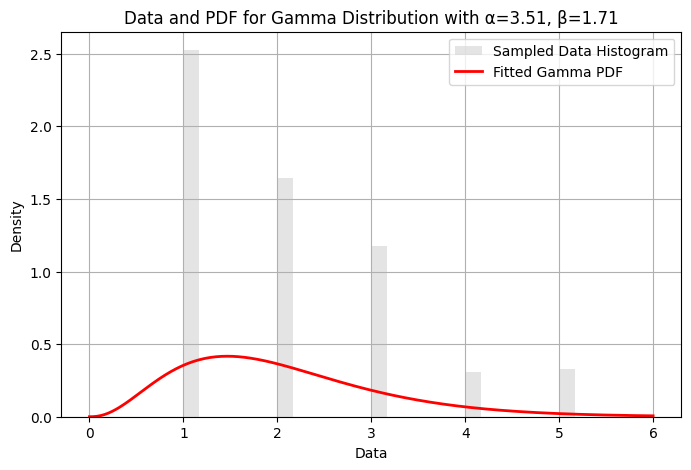

Gamma AIC : 1482.4100203899038
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 3.5078886811974797
Estimated beta (rate): 1.5629017071051479


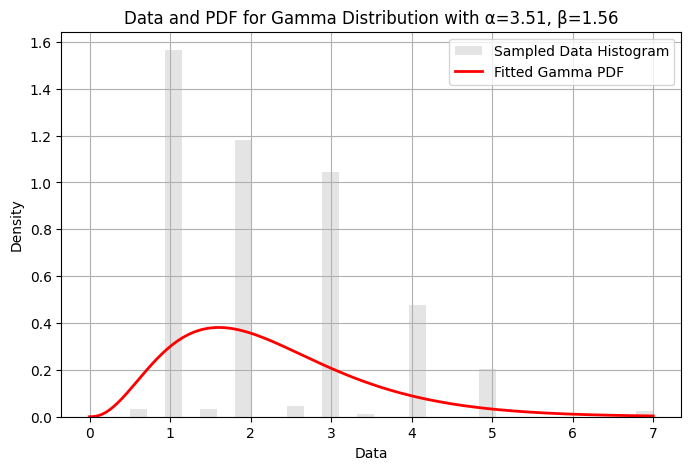

Gamma AIC : 1223.2983458811507
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 3.4288072829838647
Estimated beta (rate): 1.530029543384527


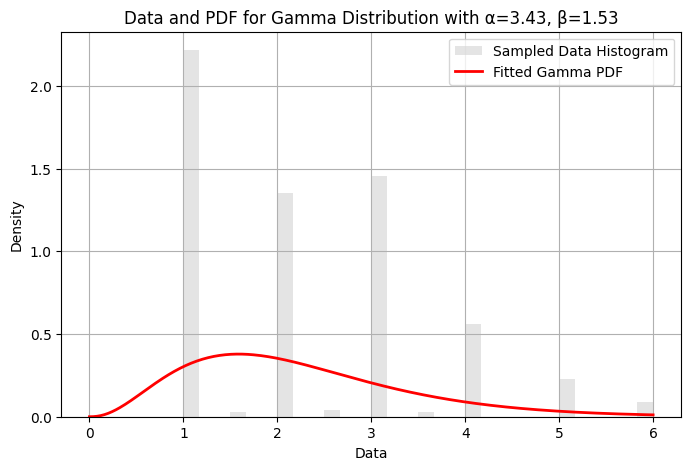

Gamma AIC : 1259.3748152547169
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 3.210282957840032
Estimated beta (rate): 1.3033199637154858


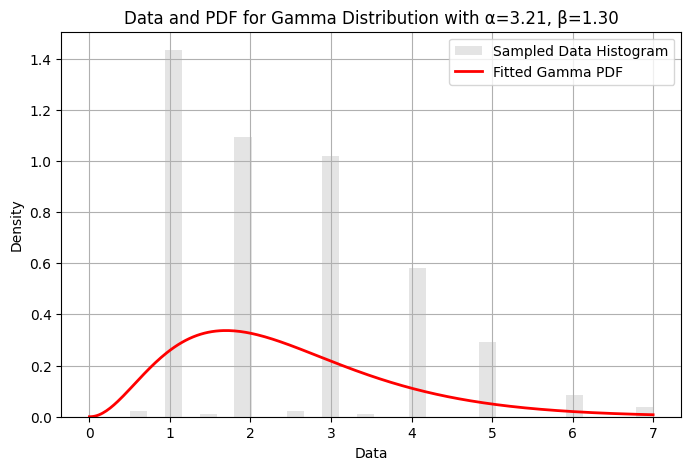

Gamma AIC : 1239.0276280093217
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 3.6010561016672145
Estimated beta (rate): 1.358537986692087


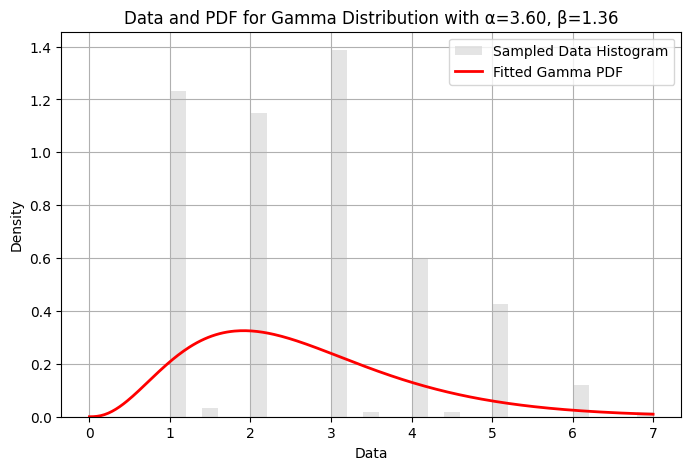

Gamma AIC : 969.9177344735235
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 3.342788978055543
Estimated beta (rate): 1.3575642291682817


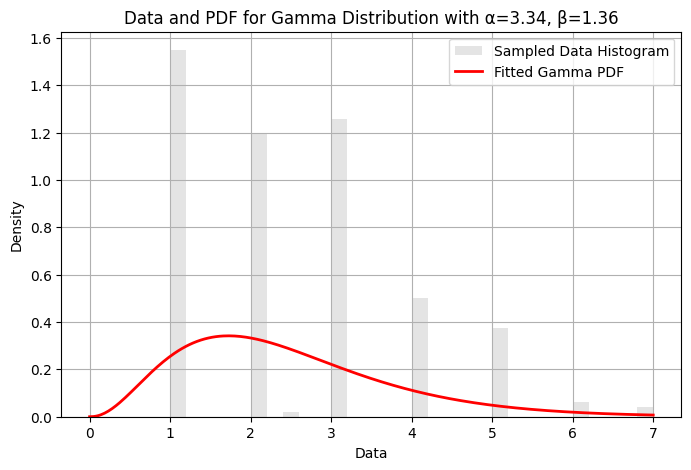

Gamma AIC : 773.2222319800522
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 3.775362857601463
Estimated beta (rate): 1.5283946258347896


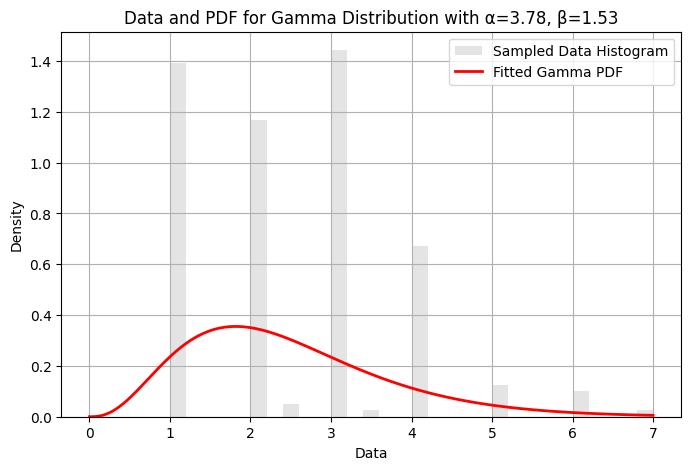

Gamma AIC : 632.9972025115876
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 3.7663285695045836
Estimated beta (rate): 1.3484834347159735


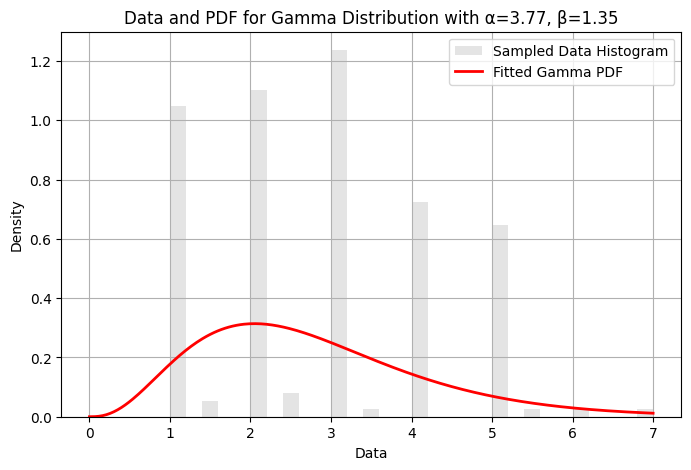

Gamma AIC : 632.1101606220449
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 3.5766258437642673
Estimated beta (rate): 1.0923690989141037


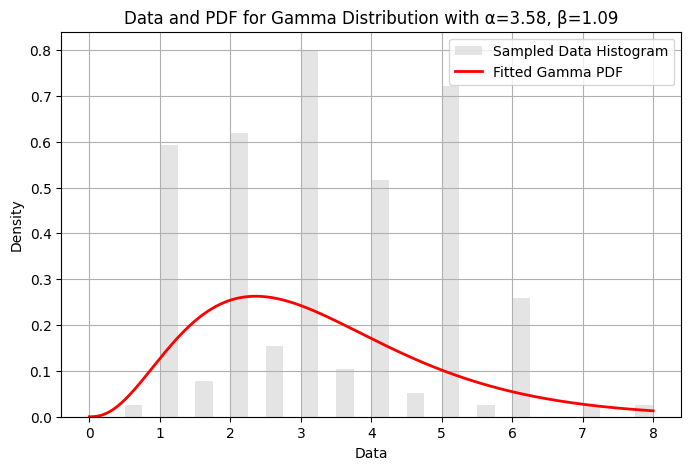

Gamma AIC : 583.0494670842539


In [65]:
pron_sup_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')[pron_sup].sum(axis=1)
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    pron_sup_label = pd.concat([pron_sup_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [66]:
pron_sup_label

,BL,V02,V04,V06,V08,V10,V12,V14,V16
PATNO,,,,,,,,,
3001,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3002,Not Worse,Not Worse,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Worse,Not Worse
3003,Worse,Worse,Worse,Worse,Worse,Worse,Not Worse,Not Worse,Not Worse
3006,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3007,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
...,...,...,...,...,...,...,...,...,...
160231,Worse,Not Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
161236,Not Worse,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
162929,Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse


In [67]:
pron_sup_label.to_csv('./../Labels/PartB_PronSupHandMove_Labels.csv')

## Toe Tapping

In [14]:
toe_tap = [
'NP3TTAPR',
'NP3TTAPL'
]

In [34]:
p3[['PATNO' , 'EVENT_ID','NP3TTAP'] + toe_tap ]

,PATNO,EVENT_ID,NP3TTAP,NP3TTAPR,NP3TTAPL
0,3001,BL,0.0,0.0,0.0
1,3001,V02,1.0,1.0,0.0
2,3001,V04,1.0,1.0,0.0
3,3001,V05,2.0,1.0,1.0
4,3001,V06,2.0,1.0,1.0
...,...,...,...,...,...
11585,163265,V16,NaN,NaN,NaN
11586,163265,V17,NaN,NaN,NaN
11587,163265,V18,NaN,NaN,NaN
11588,163265,V19,NaN,NaN,NaN


In [15]:
p3['NP3TTAP'] = [np.nan for i in range(p3.shape[0])]

p3['NP3TTAP'] = p3['NP3TTAP'].fillna(p3.dropna(subset=toe_tap).loc[: , toe_tap].sum(axis=1))

p3.pivot_table(values = 'NP3TTAP' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartB_ToeTapping_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 3.4461817494369105
Estimated beta (rate): 1.58549379285772


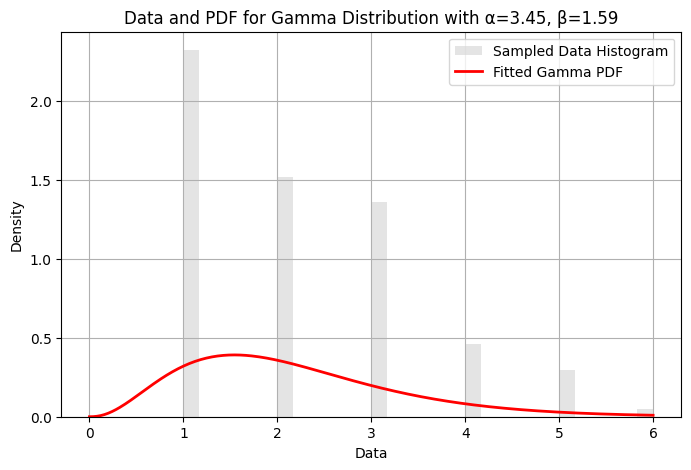

Gamma AIC : 1497.3465132432966
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 3.5310188798703526
Estimated beta (rate): 1.553956032957678


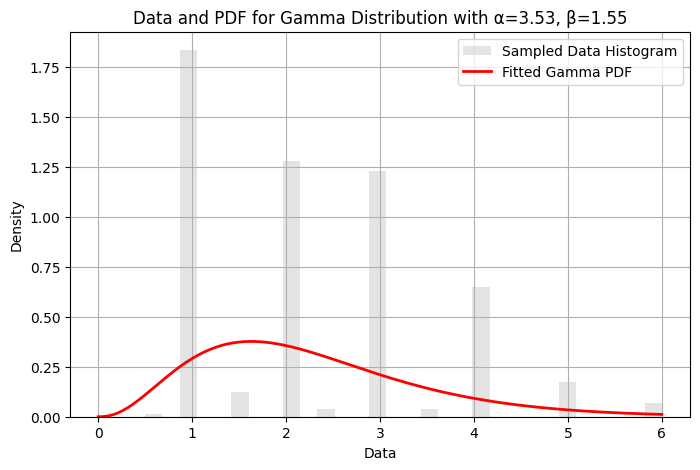

Gamma AIC : 1222.181199835577
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 3.4682042941945306
Estimated beta (rate): 1.4788466595897296


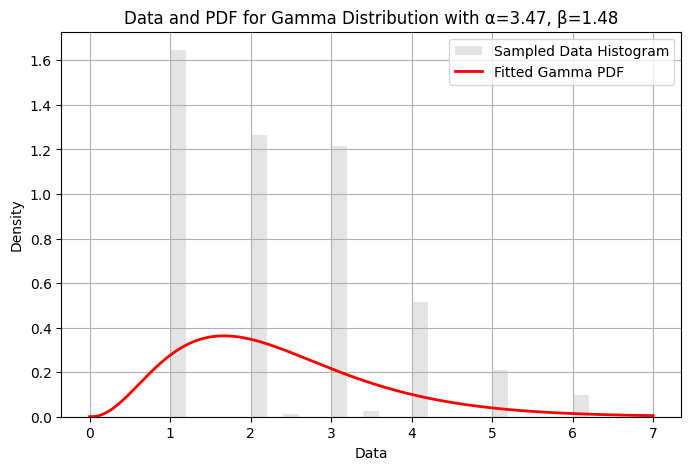

Gamma AIC : 1262.6501096433462
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 3.502172812991694
Estimated beta (rate): 1.367755038769019


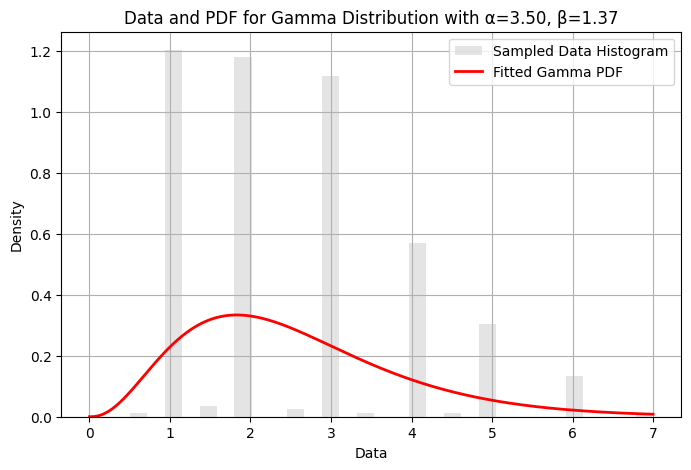

Gamma AIC : 1243.019867176763
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 3.7101572213931524
Estimated beta (rate): 1.3680921628912497


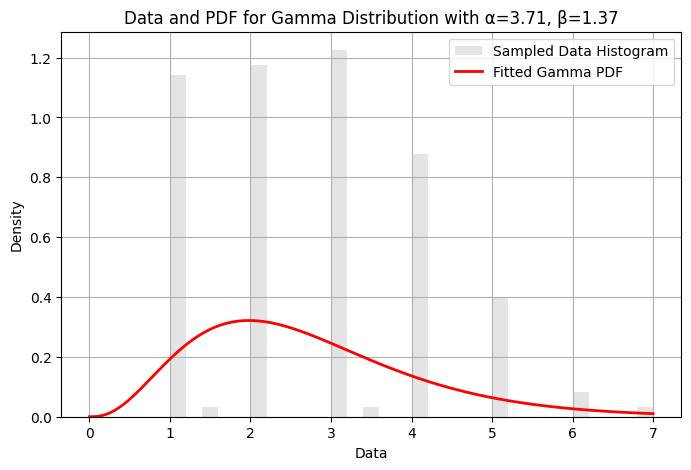

Gamma AIC : 1009.6553798133201
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 3.693358110137529
Estimated beta (rate): 1.318665704893585


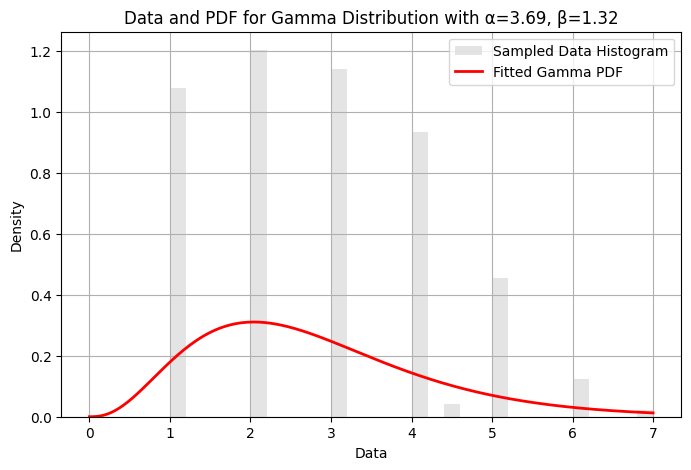

Gamma AIC : 822.9441908032112
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 3.513689897634438
Estimated beta (rate): 1.2157071036264737


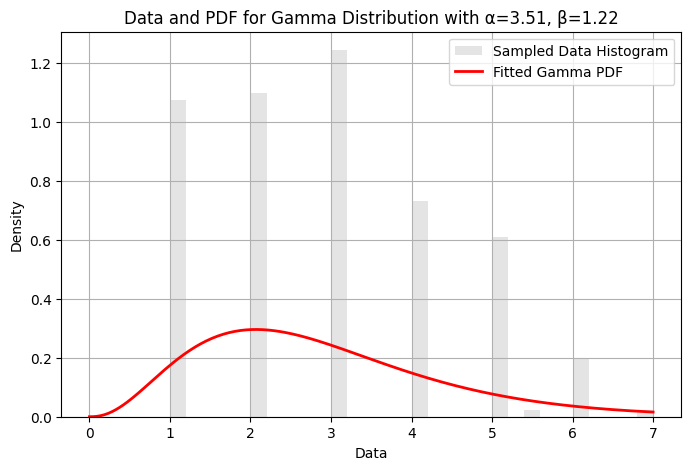

Gamma AIC : 721.5549816337704
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 3.3913928573926015
Estimated beta (rate): 1.1225866384155738


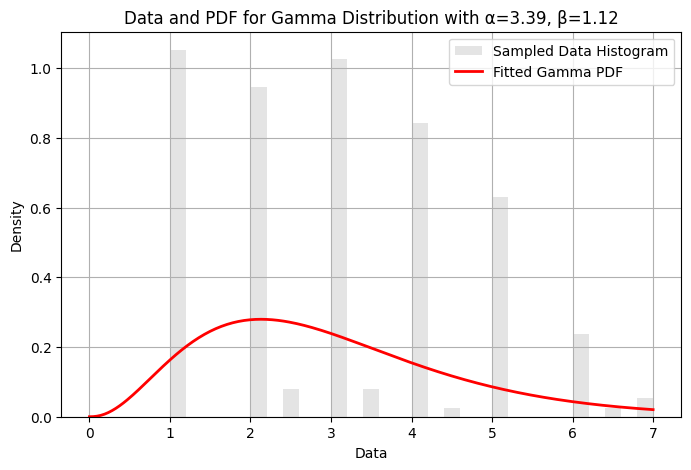

Gamma AIC : 691.1067575538912
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 4.1873675967460855
Estimated beta (rate): 1.15538322630592


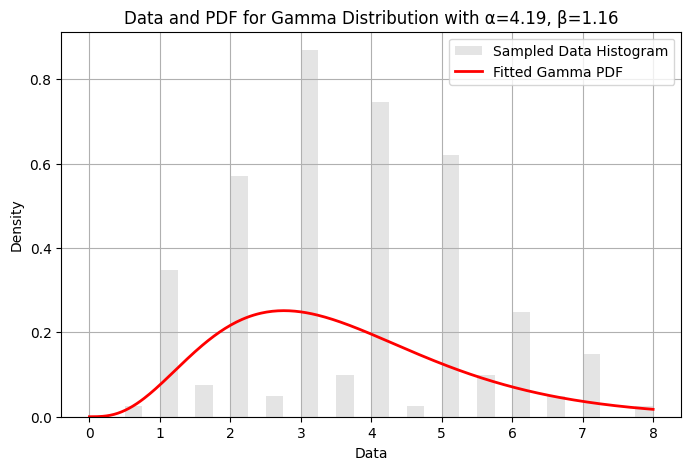

Gamma AIC : 617.7525294893903


In [26]:
toe_tap_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')[toe_tap].sum(axis=1)
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    toe_tap_label = pd.concat([toe_tap_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [27]:
toe_tap_label

,BL,V02,V04,V06,V08,V10,V12,V14,V16
PATNO,,,,,,,,,
3001,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Not Worse
3002,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Worse,Not Worse
3003,Not Worse,Not Worse,Not Worse,Not Worse,Worse,Worse,Not Worse,Not Worse,Not Worse
3006,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3007,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
...,...,...,...,...,...,...,...,...,...
160231,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
161236,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
162929,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse


In [28]:
toe_tap_label.to_csv('./../Labels/PartB_ToeTapping_Labels.csv')

## Leg Agility

In [16]:
leg_agility = ['NP3LGAGR',
'NP3LGAGL']

In [17]:
p3['NP3LAG'] = [np.nan for i in range(p3.shape[0])]

p3['NP3LAG'] = p3['NP3LAG'].fillna(p3.dropna(subset=leg_agility).loc[: , leg_agility].sum(axis=1))

p3.pivot_table(values = 'NP3LAG' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartB_LegAgility_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 3.810015346333812
Estimated beta (rate): 2.1813968660784497


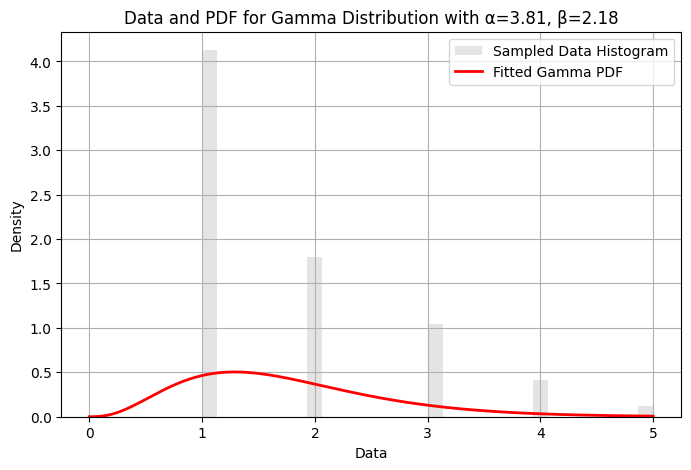

Gamma AIC : 895.3719586044474
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 3.531974418772806
Estimated beta (rate): 1.9234845369744449


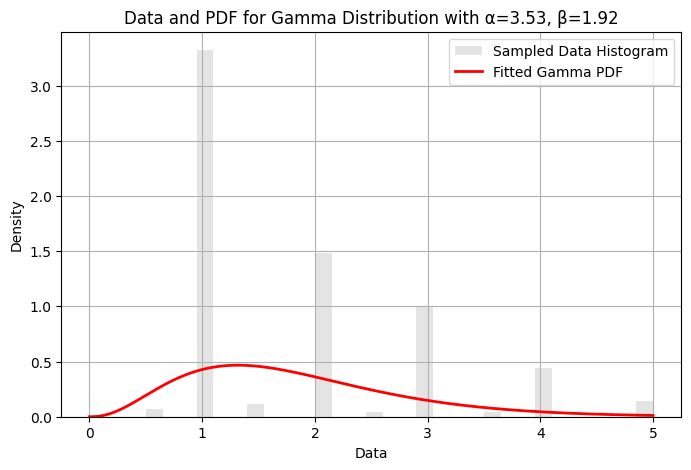

Gamma AIC : 747.0314414285192
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 3.510691959224132
Estimated beta (rate): 1.8633185667180823


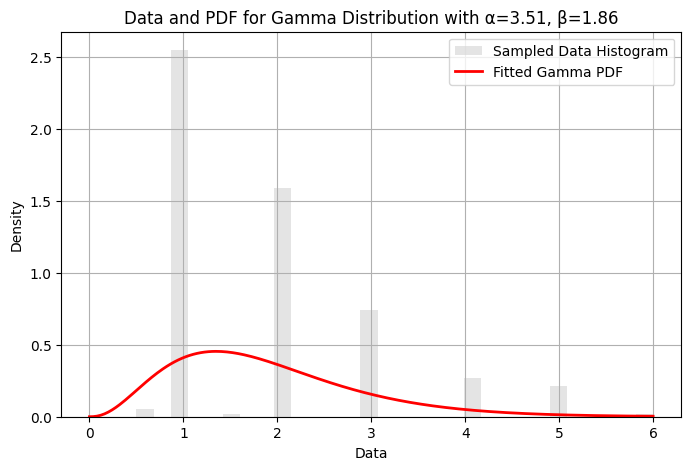

Gamma AIC : 802.8385831924098
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 3.08220589505678
Estimated beta (rate): 1.4660198370826087


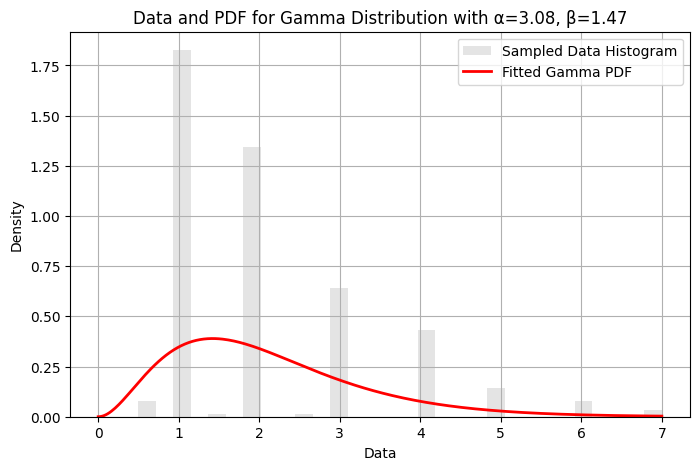

Gamma AIC : 857.6403438835827
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 3.2540544748027824
Estimated beta (rate): 1.483419579689361


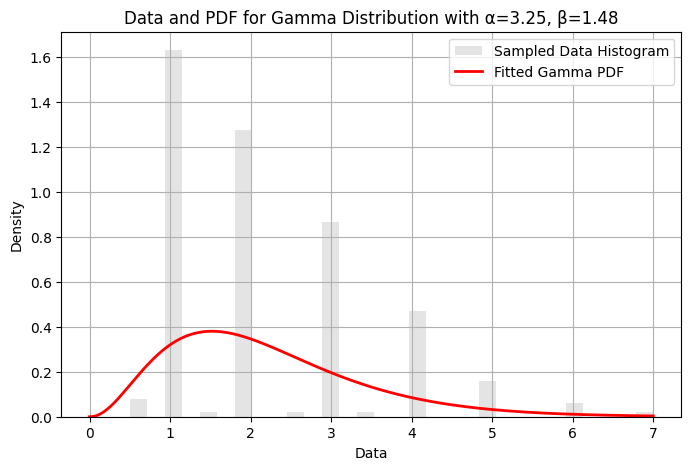

Gamma AIC : 710.8771847181854
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 3.369089558267921
Estimated beta (rate): 1.4007940098663283


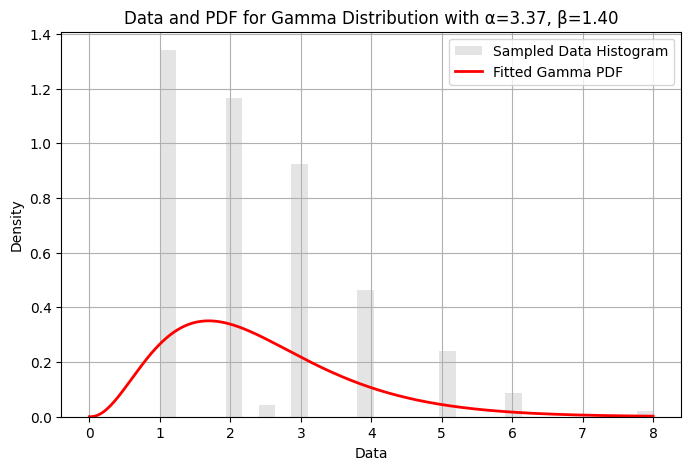

Gamma AIC : 621.2614639157819
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 2.969291348545509
Estimated beta (rate): 1.2286722580653637


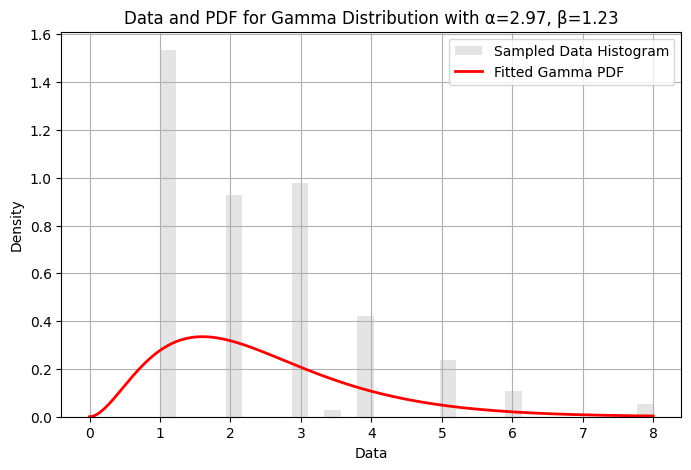

Gamma AIC : 533.7887141766446
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 4.030908980549175
Estimated beta (rate): 1.534583403690796


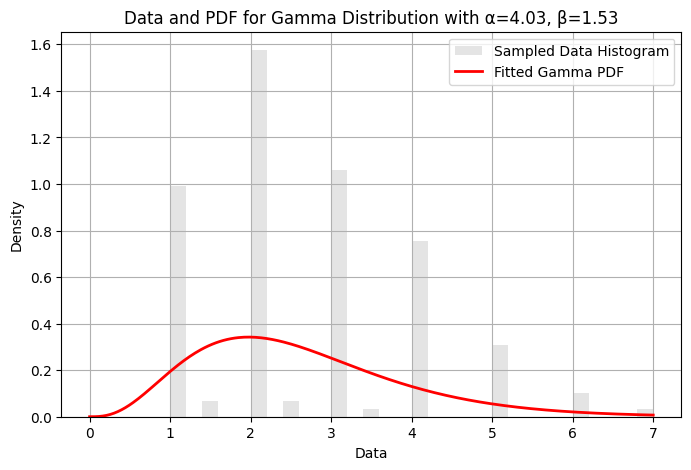

Gamma AIC : 471.11763724647926
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 3.2761433747657707
Estimated beta (rate): 1.106643871751485


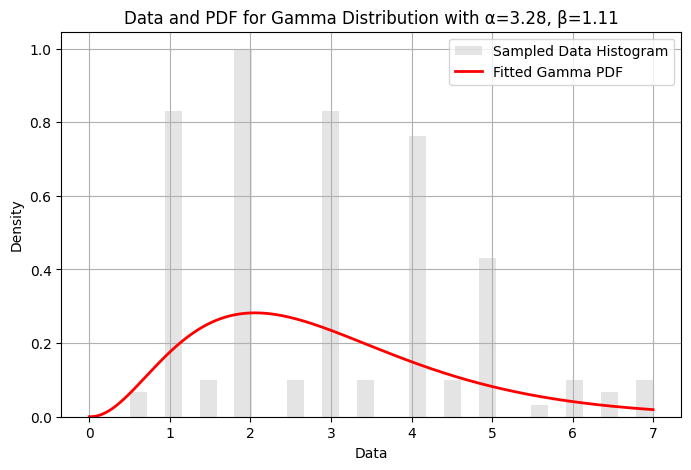

Gamma AIC : 504.73231733446215


In [30]:
leg_agility_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')[leg_agility].sum(axis=1)
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    leg_agility_label = pd.concat([leg_agility_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [31]:
leg_agility_label

,BL,V02,V04,V06,V08,V10,V12,V14,V16
PATNO,,,,,,,,,
3001,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3002,Worse,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Not Worse,Worse,Not Worse
3003,Not Worse,Worse,Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3006,Worse,Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3007,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
...,...,...,...,...,...,...,...,...,...
160231,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
161236,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
162929,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse


In [32]:
leg_agility_label.to_csv('./../Labels/PartB_LegAgility_Labels.csv')

## Postural Tremor of Hands

In [18]:
post_hand_trem = [
'NP3PTRMR',
'NP3PTRML']

In [19]:
p3['NP3HTRM'] = [np.nan for i in range(p3.shape[0])]

p3['NP3HTRM'] = p3['NP3HTRM'].fillna(p3.dropna(subset=post_hand_trem).loc[: , post_hand_trem].sum(axis=1))

p3.pivot_table(values = 'NP3HTRM' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartB_PosturalHandTremor_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 5.880144733115919
Estimated beta (rate): 4.002973574942719


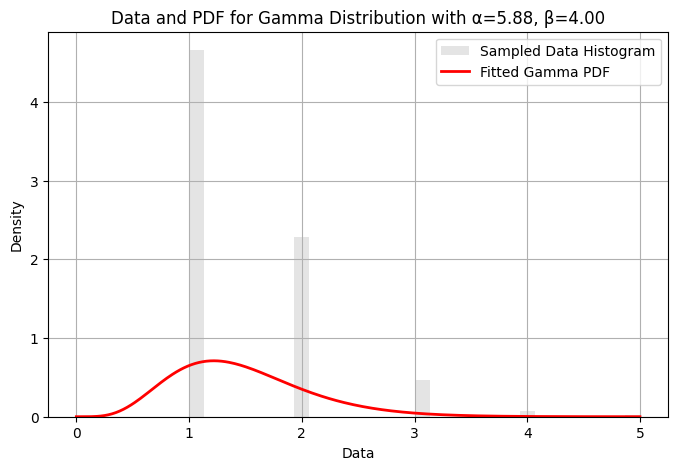

Gamma AIC : 556.9039079419626
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 4.611657061162613
Estimated beta (rate): 2.9138326419791416


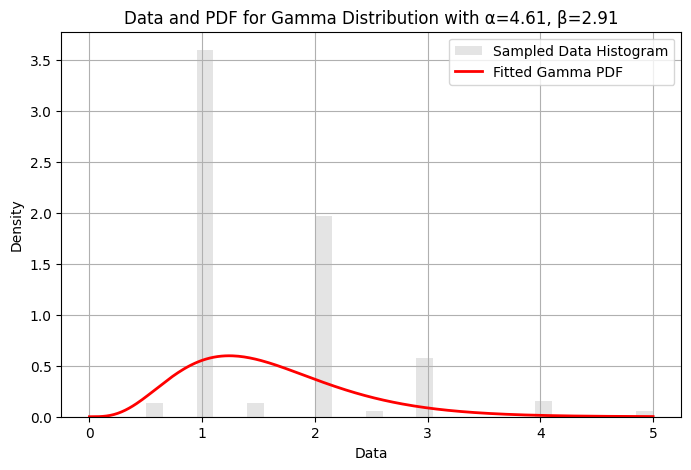

Gamma AIC : 531.0352006456031
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 4.3458817674600665
Estimated beta (rate): 2.6499274188290416


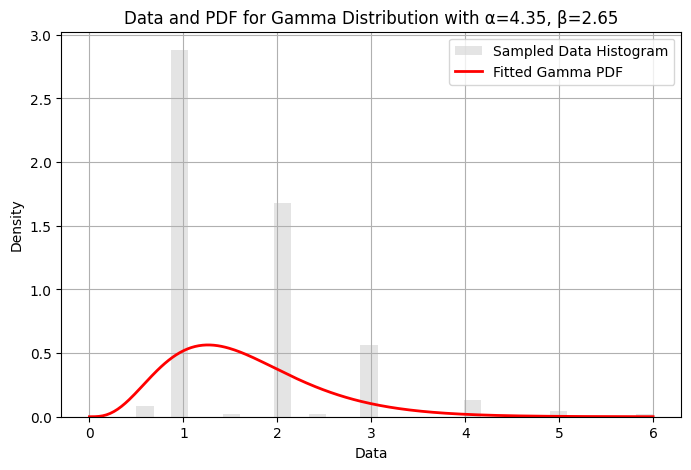

Gamma AIC : 552.8988260768222
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 4.481327276808453
Estimated beta (rate): 2.7134636014314744


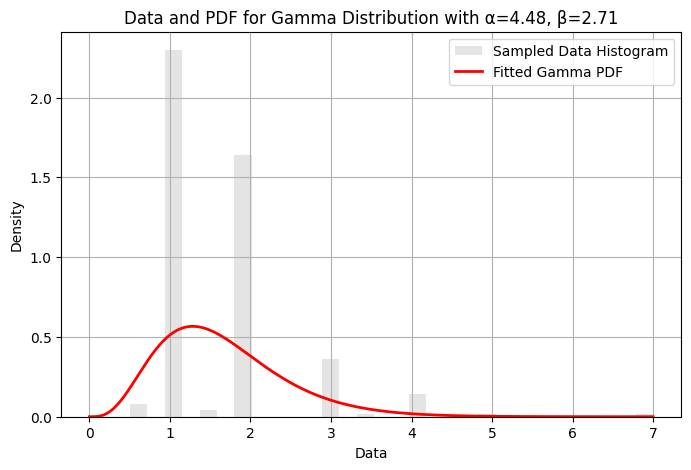

Gamma AIC : 508.5220577614497
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 4.375571027011666
Estimated beta (rate): 2.6253424103333542


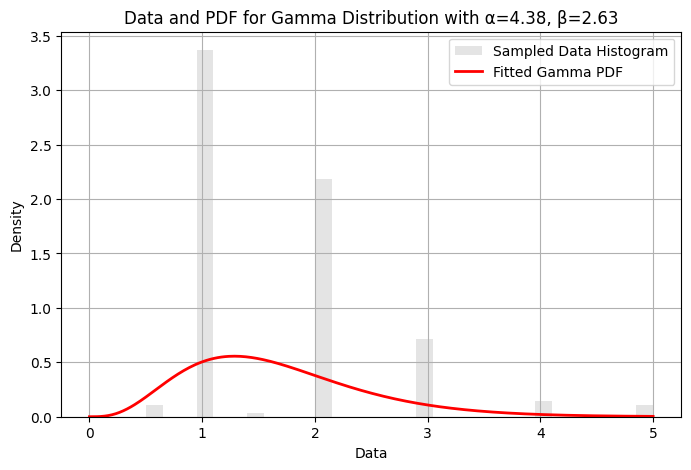

Gamma AIC : 417.3310395268135
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 3.740927937492604
Estimated beta (rate): 2.0183009546131325


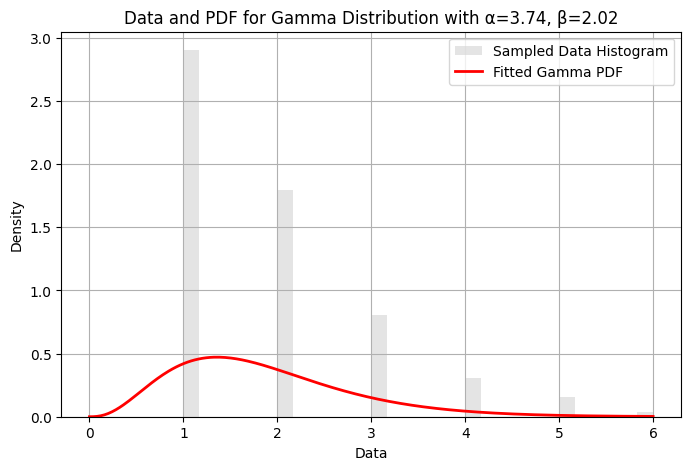

Gamma AIC : 406.2732714152595
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 3.7337684896918053
Estimated beta (rate): 1.929113274876595


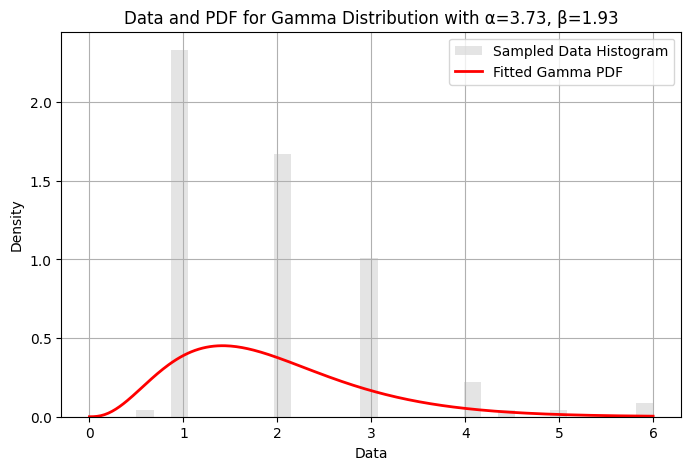

Gamma AIC : 332.64171489220234
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 3.736536285177215
Estimated beta (rate): 1.9229871131999476


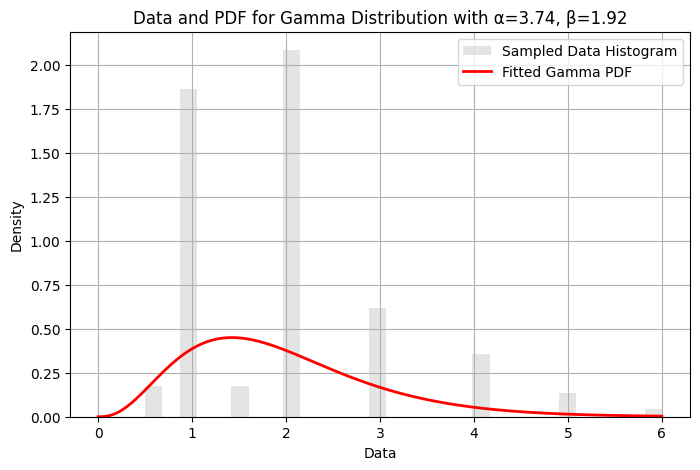

Gamma AIC : 330.8835209089076
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 3.32444048259336
Estimated beta (rate): 1.5504111179224687


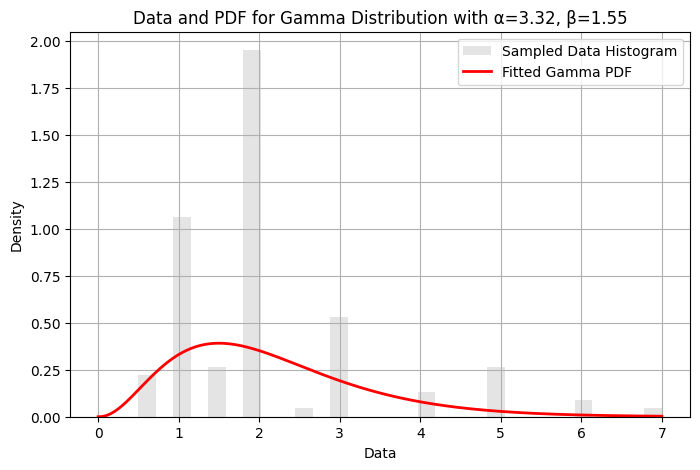

Gamma AIC : 310.39131038469804


In [34]:
post_hand_trem_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')[post_hand_trem].sum(axis=1)
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    post_hand_trem_label = pd.concat([post_hand_trem_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [35]:
post_hand_trem_label

,BL,V02,V04,V06,V08,V10,V12,V14,V16
PATNO,,,,,,,,,
3001,Not Worse,Worse,Worse,Not Worse,Not Worse,Worse,Worse,Not Worse,Not Worse
3002,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3003,Not Worse,Not Worse,Not Worse,Worse,Not Worse,Worse,Not Worse,Not Worse,Not Worse
3006,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3007,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
...,...,...,...,...,...,...,...,...,...
160231,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
161236,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
162929,Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse


In [36]:
post_hand_trem_label.to_csv('./../Labels/PartB_PosturalHandTremor_Labels.csv')

## Kinetic Tremor of Hands

In [21]:
kin_trem_hand = [
'NP3KTRMR',
'NP3KTRML'
]

In [22]:
p3['NP3HTRM'] = [np.nan for i in range(p3.shape[0])]

p3['NP3HTRM'] = p3['NP3HTRM'].fillna(p3.dropna(subset=kin_trem_hand).loc[: , kin_trem_hand].sum(axis=1))

p3.pivot_table(values = 'NP3HTRM' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartB_KineticHandTremor_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 5.526821568970679
Estimated beta (rate): 3.47779929267879


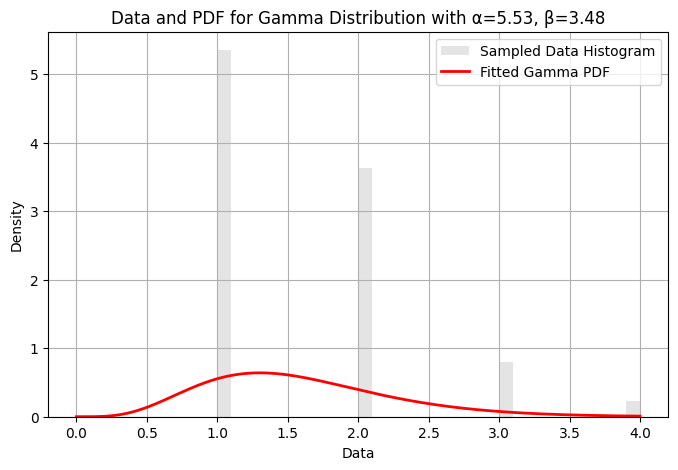

Gamma AIC : 609.548091667955
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 4.839115191909666
Estimated beta (rate): 2.880569002689787


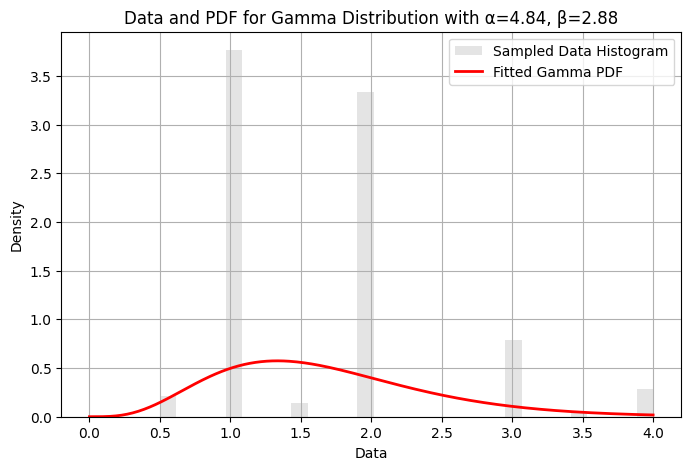

Gamma AIC : 518.7072417877271
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 5.116018315271373
Estimated beta (rate): 2.9781651890642613


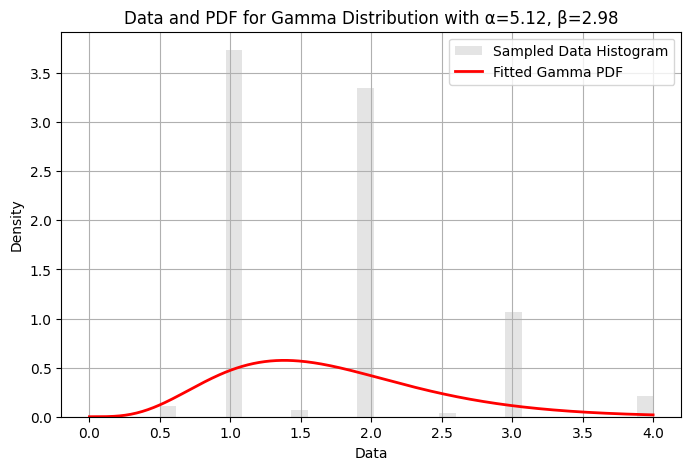

Gamma AIC : 522.3479450385169
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 4.972804723030967
Estimated beta (rate): 2.851074626071026


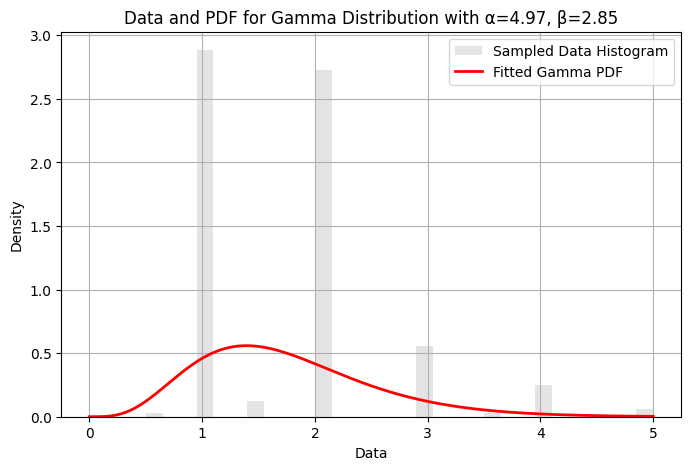

Gamma AIC : 478.1859739450878
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 4.5996529141116165
Estimated beta (rate): 2.7581099582900297


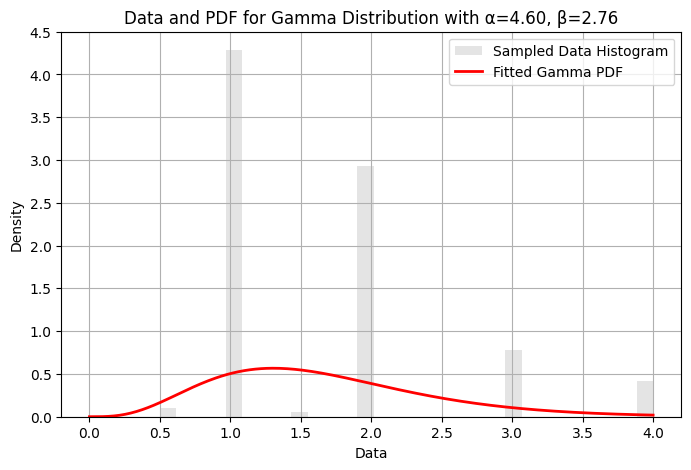

Gamma AIC : 361.80916111485453
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 4.589447692516614
Estimated beta (rate): 2.4942650965604343


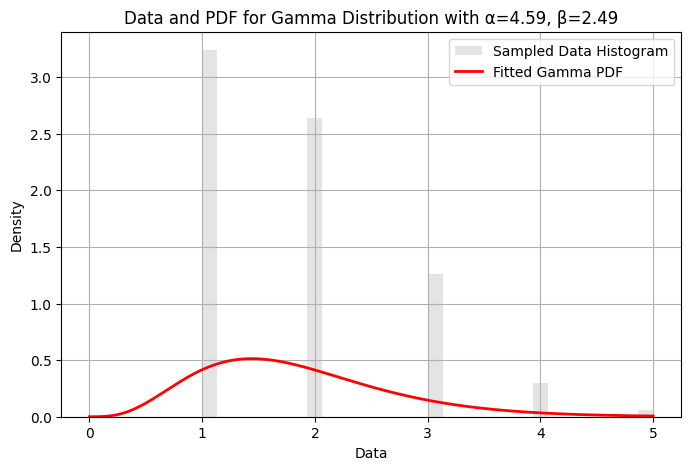

Gamma AIC : 301.5358382766064
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 5.0734964809140966
Estimated beta (rate): 2.910178314801457


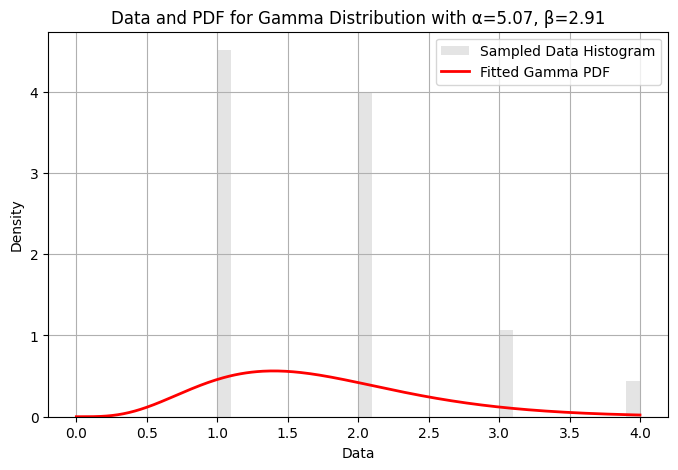

Gamma AIC : 251.18300895716055
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 3.9906757982357104
Estimated beta (rate): 2.0699300188004877


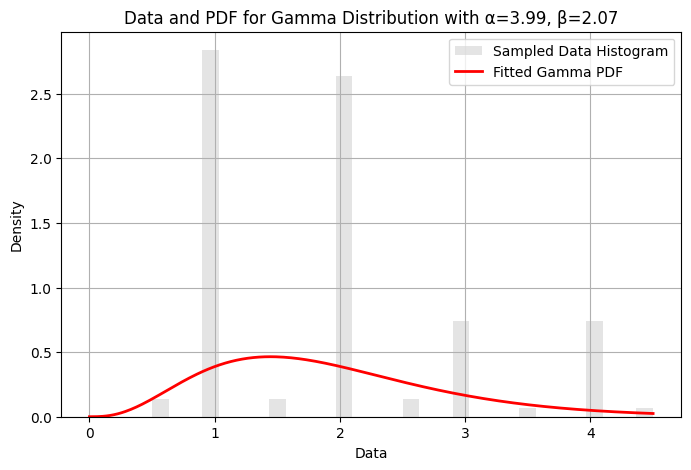

Gamma AIC : 291.3801391712715
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 4.27523714830725
Estimated beta (rate): 2.2016190846719916


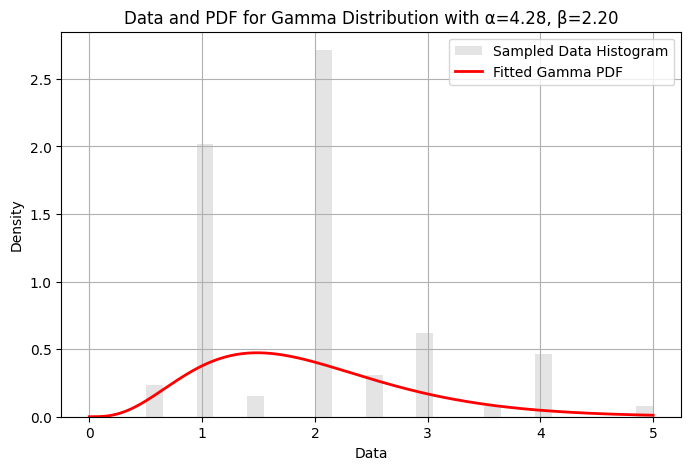

Gamma AIC : 223.04595403986278


In [38]:
kin_trem_hand_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')[kin_trem_hand].sum(axis=1)
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    kin_trem_hand_label = pd.concat([kin_trem_hand_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [39]:
kin_trem_hand_label

,BL,V02,V04,V06,V08,V10,V12,V14,V16
PATNO,,,,,,,,,
3001,Not Worse,Worse,Worse,Worse,Not Worse,Worse,Not Worse,Worse,Worse
3002,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3003,Not Worse,Not Worse,Not Worse,Worse,Worse,Worse,Not Worse,Not Worse,Not Worse
3006,Not Worse,Not Worse,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
3007,Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
...,...,...,...,...,...,...,...,...,...
160231,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
161236,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse
162929,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse,Not Worse


In [40]:
kin_trem_hand_label.to_csv('./../Labels/PartB_KineticHandTremor_Labels.csv')

## Rest Tremor Amplitude

In [23]:
rest_trem = [
'NP3RTARU',
'NP3RTALU',
'NP3RTARL',
'NP3RTALL',
'NP3RTALJ']

In [24]:
p3['NP3RTRM'] = [np.nan for i in range(p3.shape[0])]

p3['NP3RTRM'] = p3['NP3RTRM'].fillna(p3.dropna(subset=rest_trem).loc[: , rest_trem].sum(axis=1))

p3.pivot_table(values = 'NP3RTRM' , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv('./../Labels/PartB_RestTremorAmp_Scores.csv')

Distribution for event BL
There are 610 assessments at this event
Estimated alpha (shape): 3.9844556067278503
Estimated beta (rate): 1.8145767560964285


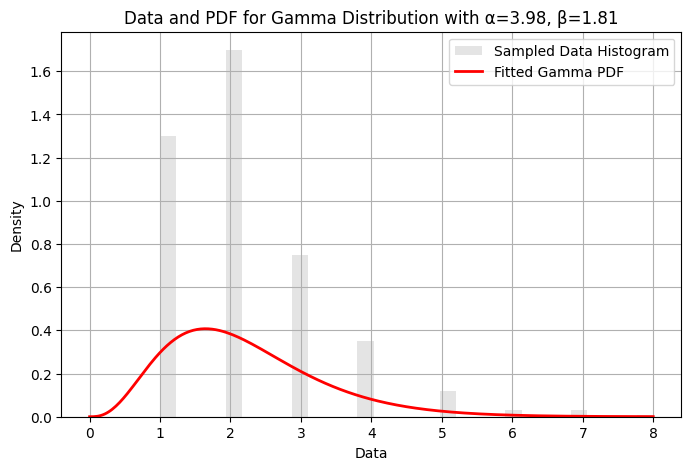

Gamma AIC : 1226.8561059283115
Distribution for event V02
There are 610 assessments at this event
Estimated alpha (shape): 3.106067757321983
Estimated beta (rate): 1.221588210581027


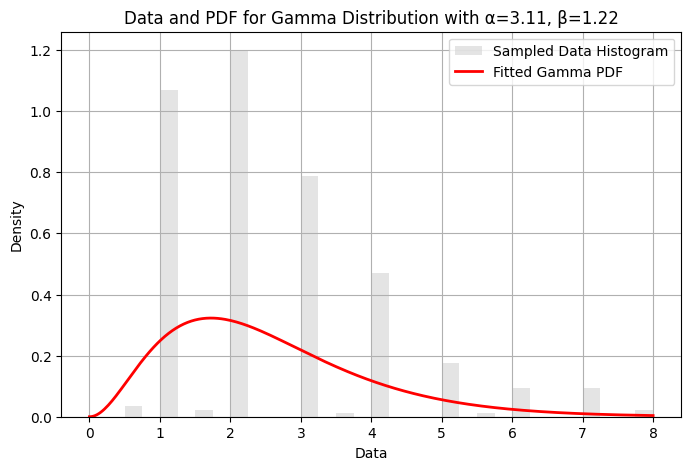

Gamma AIC : 1139.0836785388874
Distribution for event V04
There are 610 assessments at this event
Estimated alpha (shape): 3.560057671332994
Estimated beta (rate): 1.329140330856882


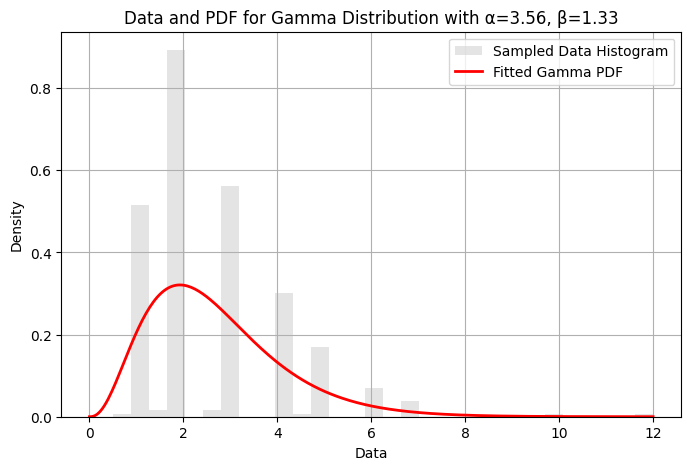

Gamma AIC : 1135.5139047609507
Distribution for event V06
There are 610 assessments at this event
Estimated alpha (shape): 2.88392979272306
Estimated beta (rate): 1.0235826213360668


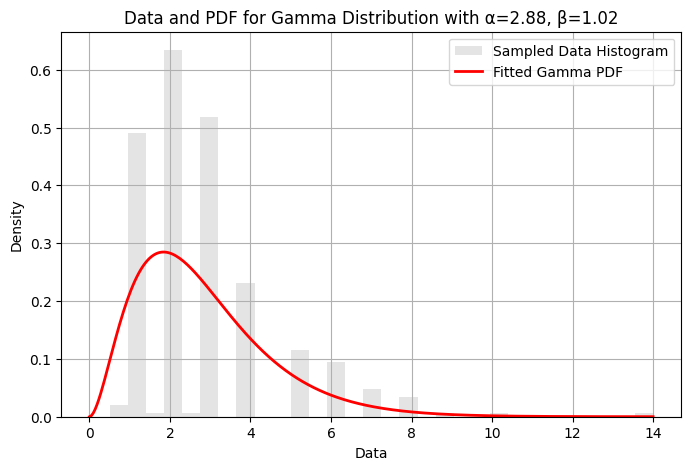

Gamma AIC : 1177.128081610771
Distribution for event V08
There are 610 assessments at this event
Estimated alpha (shape): 2.779574423323131
Estimated beta (rate): 0.9052397153394942


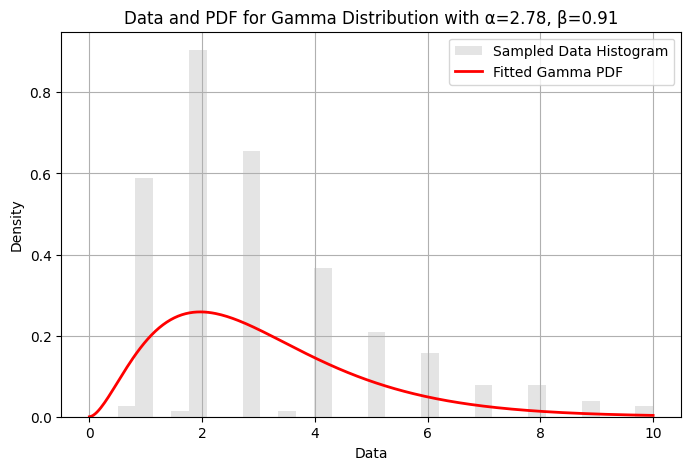

Gamma AIC : 919.1130257531023
Distribution for event V10
There are 610 assessments at this event
Estimated alpha (shape): 3.1538111278614305
Estimated beta (rate): 0.9747215678254034


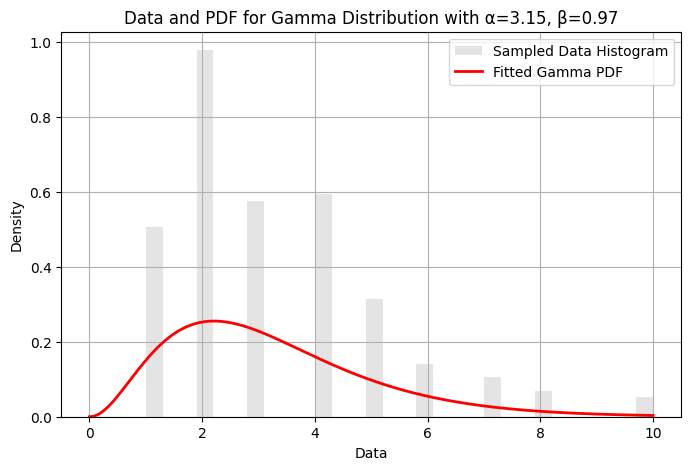

Gamma AIC : 731.5258207568593
Distribution for event V12
There are 610 assessments at this event
Estimated alpha (shape): 2.872068165384048
Estimated beta (rate): 0.8236077432386576


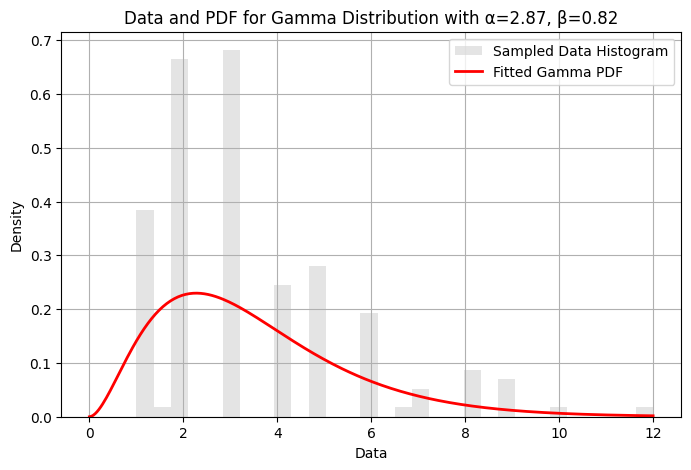

Gamma AIC : 632.374760261454
Distribution for event V14
There are 610 assessments at this event
Estimated alpha (shape): 2.628332965759933
Estimated beta (rate): 0.7165995514203356


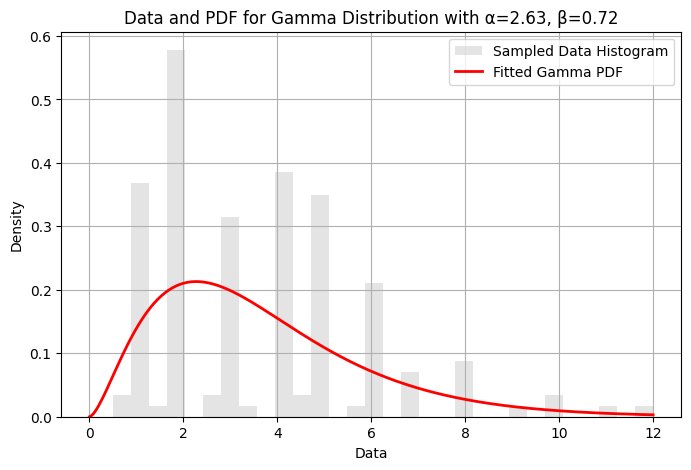

Gamma AIC : 628.6232465977669
Distribution for event V16
There are 610 assessments at this event
Estimated alpha (shape): 2.41894330922528
Estimated beta (rate): 0.6158259033946575


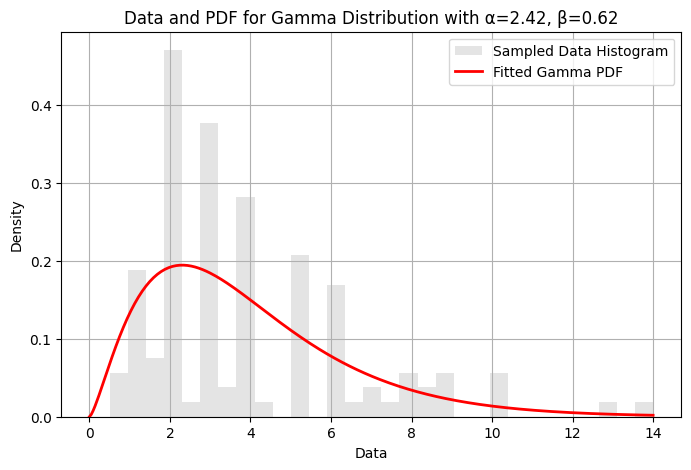

Gamma AIC : 521.5109205621158


In [42]:
rest_trem_label = pd.DataFrame()

for event in p3['EVENT_ID'].unique() : 
    print(f'Distribution for event {event}')
    data = p3[p3['EVENT_ID'] == event].set_index('PATNO')[rest_trem].sum(axis=1)
    n_events = data.shape[0]
    print(f'There are {n_events} assessments at this event')
    data_filt = data[data>0]
    alpha_est , beta_est = fit_gamma_distribution(data_filt)
    aic_score = calculate_gamma_aic(data_filt, (alpha_est , beta_est))
    labels = gamma_significance_classify(data , alpha_est , beta_est , 'Worse' , thresh=0.2)
    rest_trem_label = pd.concat([rest_trem_label , pd.DataFrame(labels , index=data.index , columns=[event])] , axis=1)
    print(f'Gamma AIC : {aic_score}')

In [43]:
rest_trem_label.to_csv('./../Labels/PartB_RestTremorAmp_Labels.csv')